In [1]:
import pandas as pd
import numpy as np
import os

In [5]:
STRATIFIED_DATA_FILE = "../real_vase_data/profiles_stratified_120526.parquet"
ALL_DATA_FILE = "../real_vase_data/all_profiles_120526.parquet"
METADATA_FILE = "../real_vase_data/master_metadata.csv"
OUT_DIR = "../file_processing/pca_csv"

In [6]:
meta_data = pd.read_csv(METADATA_FILE, encoding='latin1', dtype=str)
stratified_data = pd.read_parquet(STRATIFIED_DATA_FILE)
profile_data = pd.read_parquet(ALL_DATA_FILE)

In [7]:
meta_data['gpp_no'] = meta_data['gpp_no'].astype(str).str.strip()
stratified_data['gpp_no'] = stratified_data['gpp_no'].astype(str).str.strip()
profile_data['gpp_no'] = profile_data['gpp_no'].astype(str).str.strip()
profile_data['gpp_no'] = profile_data['gpp_no'].str.replace('_large', '').str.replace('(1)', '').str.replace('jpeg', '')

merged_data = pd.merge(meta_data, profile_data, on='gpp_no')
print(f"Merged: {merged_data['gpp_no'].nunique()} pots")

Merged: 107474 pots


In [8]:
stratified_gpps = stratified_data['gpp_no'].unique()
merged_data = merged_data[merged_data['gpp_no'].isin(stratified_gpps)]
print(f"After stratified filter: {merged_data['gpp_no'].nunique()} pots")

After stratified filter: 53152 pots


In [10]:
from pca_func_new import pca_project

pca_df, d, gone_list = pca_project(merged_data, OUT_DIR)
pca_df.to_csv(f'{OUT_DIR}/pca_scores.csv', index=False)
print(f"Saved {len(pca_df)} pot scores → {OUT_DIR}/pca_scores.csv")

Removed 0 vases.
0 by height-to-width ratio and 0 by width ratio.


Adding culture_general: 100%|██████████| 53152/53152 [00:00<00:00, 3946811.48it/s]


Saved 53152 pot scores → ../file_processing/pca_csv/pca_scores.csv


=== PCA Reconstruction Diagnostics (6 PCs) ===
R² (variance captured by projection): 0.9795
Overall RMSE:  0.0376
Per-pot RMSE — mean: 0.0345, median: 0.0309, max: 0.2766

=== Variance Explained per PC ===
  PC1: 57.97%  (cumulative: 57.97%)
  PC2: 24.10%  (cumulative: 82.07%)
  PC3: 9.05%  (cumulative: 91.12%)
  PC4: 3.64%  (cumulative: 94.76%)
  PC5: 2.22%  (cumulative: 96.98%)
  PC6: 0.97%  (cumulative: 97.95%)

=== PC Score Distributions ===
             PC1        PC2        PC3        PC4        PC5        PC6
count  53152.000  53152.000  53152.000  53152.000  53152.000  53152.000
mean      -0.000     -0.000      0.000     -0.000     -0.000     -0.000
std        4.478      2.887      1.769      1.122      0.876      0.580
min       -8.607     -8.091     -8.235     -7.130     -3.384     -3.741
25%       -3.737     -2.342     -1.131     -0.637     -0.517     -0.395
50%       -1.411      0.122     -0.118      0.052     -0.065     -0.028
75%        3.774      2.325      0.906      0.

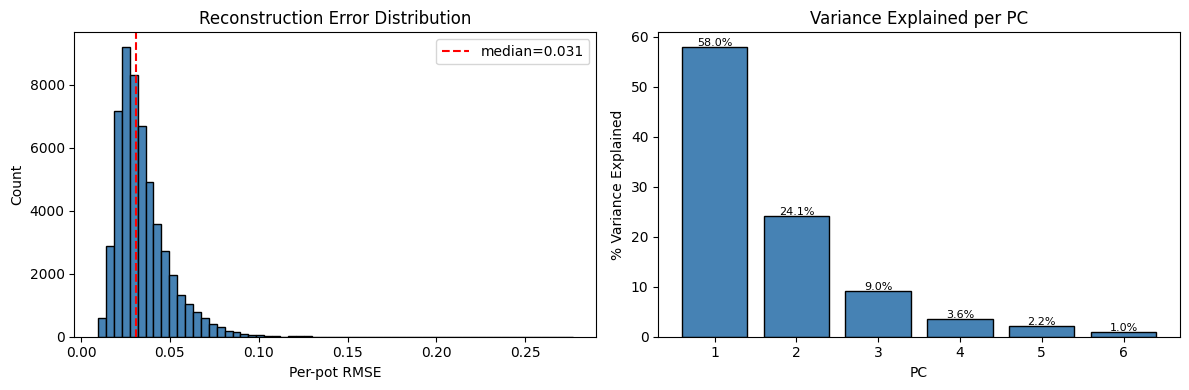

In [11]:
import matplotlib.pyplot as plt

# Load the same components/means used in projection
components = pd.read_csv(f'{OUT_DIR}/pc_vals.csv', index_col=0).values
means = pd.read_csv(f'{OUT_DIR}/pc_val_means.csv')['pc_mean'].values

X = d.drop(columns=['gpp_no']).values
X_centered = X - means
pc_cols = [c for c in pca_df.columns if c.startswith('PC')]
scores = pca_df[pc_cols].values

# --- Reconstruction ---
X_reconstructed = scores @ components + means
residuals = X - X_reconstructed
per_pot_rmse = np.sqrt((residuals ** 2).mean(axis=1))
overall_rmse = np.sqrt((residuals ** 2).mean())

ss_res = (residuals ** 2).sum()
ss_tot = (X_centered ** 2).sum()
r_squared = 1 - ss_res / ss_tot

print(f"=== PCA Reconstruction Diagnostics ({len(pc_cols)} PCs) ===")
print(f"R² (variance captured by projection): {r_squared:.4f}")
print(f"Overall RMSE:  {overall_rmse:.4f}")
print(f"Per-pot RMSE — mean: {per_pot_rmse.mean():.4f}, "
      f"median: {np.median(per_pot_rmse):.4f}, max: {per_pot_rmse.max():.4f}")

# --- Variance explained per PC ---
total_var = (X_centered ** 2).sum() / X_centered.shape[0]          # mean total variance
pc_var = np.var(scores, axis=0, ddof=0)                             # eigenvalue proxy
pc_pct = pc_var / total_var * 100

print(f"\n=== Variance Explained per PC ===")
for i, (v, p) in enumerate(zip(pc_var, pc_pct), 1):
    print(f"  PC{i}: {p:.2f}%  (cumulative: {pc_pct[:i].sum():.2f}%)")

# --- PC score statistics ---
print(f"\n=== PC Score Distributions ===")
print(pca_df[pc_cols].describe().round(3))

# --- 5 worst reconstructed pots ---
worst_idx = np.argsort(per_pot_rmse)[-5:][::-1]
print(f"\n=== 5 Worst Reconstructed Pots ===")
print(pd.DataFrame({'gpp_no': d['gpp_no'].values[worst_idx],
                    'rmse': per_pot_rmse[worst_idx].round(4)}))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(per_pot_rmse, bins=60, edgecolor='k', color='steelblue')
axes[0].set_xlabel('Per-pot RMSE')
axes[0].set_ylabel('Count')
axes[0].set_title('Reconstruction Error Distribution')
axes[0].axvline(np.median(per_pot_rmse), color='red', linestyle='--', label=f'median={np.median(per_pot_rmse):.3f}')
axes[0].legend()

axes[1].bar(range(1, len(pc_cols) + 1), pc_pct, color='steelblue', edgecolor='k')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('% Variance Explained')
axes[1].set_title('Variance Explained per PC')
axes[1].set_xticks(range(1, len(pc_cols) + 1))
for i, p in enumerate(pc_pct):
    axes[1].text(i + 1, p + 0.2, f'{p:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()